(numba_lecture)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# Numba

علاوه بر آنچه در Anaconda موجود است، این درس به کتابخانه‌های زیر نیاز دارد:

In [1]:
!pip install quantecon

لطفاً اطمینان حاصل کنید که آخرین نسخه Anaconda را دارید، زیرا نسخه‌های قدیمی یک {doc}`منبع رایج خطا <troubleshooting>` هستند.

بیایید با چند import شروع کنیم:

In [2]:
import numpy as np
import quantecon as qe
import matplotlib.pyplot as plt

## مروری کلی

در یک {doc}`درس قبلی <need_for_speed>` درباره برداری‌سازی بحث کردیم،
که می‌تواند سرعت اجرا را با ارسال دسته‌ای عملیات پردازش آرایه به کد کارآمد سطح پایین بهبود بخشد.

با این حال، همانطور که {ref}`قبلاً بحث شد <numba-p_c_vectorization>`، طرح‌های سنتی برداری‌سازی چندین نقطه ضعف دارند:

* بسیار حافظه‌بر برای عملیات ترکیبی آرایه
* ناکارآمد یا غیرممکن برای برخی الگوریتم‌ها

یک راه برای دور زدن این مشکلات، استفاده از [Numba](https://numba.pydata.org/) است، یک
**کامپایلر در زمان اجرا (JIT)** برای Python.

Numba توابع را در زمان اجرا به دستورالعمل‌های کد ماشین بومی کامپایل می‌کند.

وقتی موفق می‌شود، نتیجه عملکردی قابل مقایسه با C یا Fortran کامپایل‌شده است.

علاوه بر این، Numba می‌تواند ترفندهای مفیدی مانند {ref}`چندنخی <multithreading>` نیز انجام دهد.

این درس ایده‌های اصلی را معرفی می‌کند.

```{note}
برخی خوانندگان ممکن است کنجکاو رابطه بین Numba و [Julia](https://julialang.org/) باشند،
که کامپایلر JIT خود را دارد. در حالی که این دو کامپایلر از بسیاری جهات مشابه هستند،
Numba کمتر بلندپروازانه است و تنها تلاش می‌کند زیرمجموعه کوچکی از
زبان Python را کامپایل کند. هرچند این ممکن است یک نقص به نظر برسد، اما یک مزیت نیز هست:
ماهیت محدودتر Numba استفاده از آن را آسان و در آنچه انجام می‌دهد کارآمد می‌کند.
```

(numba_link)=
## {index}`کامپایل کردن توابع <single: Compiling Functions>`

```{index} single: Python; Numba
```


(quad_map_eg)=
### یک مثال

بیایید مسئله‌ای را در نظر بگیریم که برداری‌سازی آن دشوار است (یعنی واگذاری آن به عملیات پردازش آرایه).

این مسئله شامل تولید مسیر از طریق نگاشت درجه دوم است:

$$
    x_{t+1} = \alpha x_t (1 - x_t)
$$

در ادامه، $\alpha = 4$ تعیین می‌کنیم.

#### نسخه پایه

در اینجا نمودار یک مسیر معمولی نشان داده شده است، که از $x_0 = 0.1$ شروع می‌شود، با $t$ روی محور افقی:

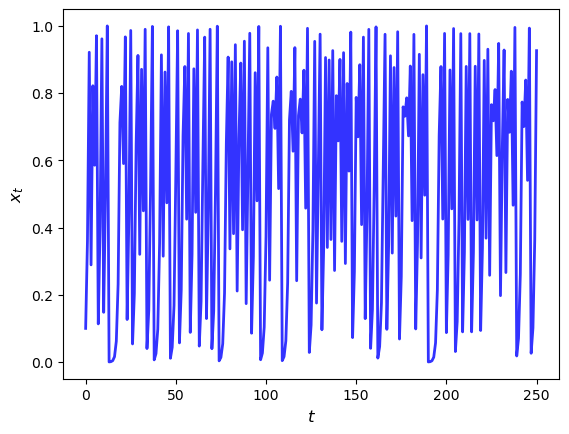

In [3]:
def qm(x0, n, α=4.0):
    x = np.empty(n+1)
    x[0] = x0
    for t in range(n):
      x[t+1] = α * x[t] * (1 - x[t])
    return x

x = qm(0.1, 250)
fig, ax = plt.subplots()
ax.plot(x, 'b-', lw=2, alpha=0.8)
ax.set_xlabel('$t$', fontsize=12)
ax.set_ylabel('$x_{t}$', fontsize = 12)
plt.show()

بیایید ببینیم برای $n$ بزرگ، اجرای این کد چقدر زمان می‌برد:

In [4]:
n = 10_000_000

with qe.Timer() as timer1:
    # Time Python base version
    x = qm(0.1, n)


2.8314 seconds elapsed


#### شتاب‌دهی از طریق Numba

برای تسریع تابع `qm` با استفاده از Numba، ابتدا تابع `jit` را وارد می‌کنیم:

In [5]:
from numba import jit

اکنون آن را روی `qm` اعمال می‌کنیم تا تابع جدیدی تولید شود:

In [6]:
qm_numba = jit(qm)

تابع `qm_numba` نسخه‌ای از `qm` است که برای کامپایل JIT «هدف‌گذاری» شده است.

معنای این موضوع را به زودی توضیح خواهیم داد.

بیایید زمان این نسخه جدید را اندازه بگیریم:

In [7]:
with qe.Timer() as timer2:
    # Time jitted version
    x = qm_numba(0.1, n)

0.1105 seconds elapsed


این یک افزایش سرعت قابل توجه است.

در واقع، در دفعه بعد و تمام اجراهای بعدی، حتی سریع‌تر اجرا می‌شود؛ زیرا تابع کامپایل شده و در حافظه ذخیره است:

(qm_numba_result)=

In [8]:
with qe.Timer() as timer3:
    # Second run
    x = qm_numba(0.1, n)

0.0203 seconds elapsed


در اینجا میزان افزایش سرعت نشان داده شده است:

In [9]:
timer1.elapsed /  timer3.elapsed

139.1538028895164

این یک بهبود چشمگیر با تغییری اندک در کد اصلی ماست.

بیایید بررسی کنیم که این چگونه کار می‌کند.

### چگونگی و شرایط عملکرد آن

Numba تلاش می‌کند با استفاده از زیرساخت ارائه‌شده توسط [پروژه LLVM](https://llvm.org/)، کد ماشین سریع تولید کند.

این کار را از طریق استنتاج اطلاعات نوع به صورت پویا انجام می‌دهد.

(برای بحث درباره انواع داده، به {doc}`درس قبلی <need_for_speed>` ما در مورد محاسبات علمی مراجعه کنید.)

ایده اصلی به این شرح است:

* پایتون بسیار انعطاف‌پذیر است و از این رو می‌توان تابع qm را با انواع داده مختلفی فراخواند.
    * برای مثال، `x0` می‌تواند یک آرایه NumPy یا یک لیست باشد، `n` می‌تواند عدد صحیح یا اعشاری باشد و غیره.
* این موضوع تولید کد ماشین کارآمد *از پیش* (یعنی قبل از زمان اجرا) را بسیار دشوار می‌سازد.
* اما هنگامی که تابع را واقعاً *فراخوانی* می‌کنیم، مثلاً با اجرای `qm(0.5, 10)`، انواع `x0`، `α` و `n` مشخص می‌شوند.
* علاوه بر این، انواع *سایر متغیرها* در `qm` *پس از مشخص شدن انواع ورودی قابل استنتاج هستند*.
* پس راهبرد Numba و سایر کامپایلرهای JIT این است که *تا زمان فراخوانی تابع صبر کنند* و سپس آن را کامپایل کنند.

این روش «کامپایل درست به موقع» (just-in-time) نامیده می‌شود.

توجه داشته باشید که اگر `qm_numba(0.5, 10)` را فراخوانی کنید و سپس `qm_numba(0.9, 20)` را اجرا کنید، کامپایل فقط در اولین فراخوانی انجام می‌شود.

این به این دلیل است که کد کامپایل‌شده در حافظه نهان ذخیره می‌شود و در صورت نیاز مجدداً استفاده می‌شود.

به همین دلیل است که در کد بالا، اجرای دوم `qm_numba` سریع‌تر است.

```{admonition} توضیح
در عمل، به جای نوشتن `qm_numba = jit(qm)`، معمولاً از نحو
*دکوراتور* استفاده می‌کنیم و `@jit` را قبل از تعریف تابع قرار می‌دهیم. این
معادل افزودن `qm = jit(qm)` پس از تعریف است.
```

## نکات ظریف

استفاده از Numba نسبتاً آسان است، اما همیشه بی‌دردسر نیست.

بیایید برخی از مشکلاتی که کاربران با آن‌ها مواجه می‌شوند را مرور کنیم.

### تعیین نوع

استنتاج موفق نوع، کلید کامپایل JIT است.

در یک محیط ایده‌آل، Numba می‌تواند تمام اطلاعات نوع لازم را استنتاج کند.

زمانی که Numba *نتواند* تمام اطلاعات نوع را استنتاج کند، خطا صادر می‌کند.

برای مثال، در حالت زیر، Numba قادر به تعیین نوع تابع `g` هنگام کامپایل `iterate` نیست.

In [10]:
@jit
def iterate(f, x0, n):
    x = x0
    for t in range(n):
        x = f(x)
    return x

# Not jitted
def g(x):
    return np.cos(x) - 2 * np.sin(x)

# This code throws an error
try:
    iterate(g, 0.5, 100)
except Exception as e:
    print(e)

Failed in nopython mode pipeline (step: nopython frontend)
non-precise type pyobject
During: typing of argument at /tmp/ipykernel_2646/946716698.py (1)

File "../../../../../../tmp/ipykernel_2646/946716698.py", line 1:
<source missing, REPL/exec in use?>

During: Pass nopython_type_inference 

This error may have been caused by the following argument(s):
- argument 0: Cannot determine Numba type of <class 'function'>


در این حالت، می‌توانیم این مشکل را به‌راحتی با کامپایل کردن `g` برطرف کنیم.

In [11]:
@jit
def g(x):
    return np.cos(x) - 2 * np.sin(x)

iterate(g, 0.5, 100)

2.223875299559663

در موارد دیگر، مانند زمانی که می‌خواهیم از توابع کتابخانه‌های خارجی مانند `SciPy` استفاده کنیم، ممکن است هیچ راه‌حل آسانی وجود نداشته باشد.

### متغیرهای سراسری

نکته دیگری که هنگام استفاده از Numba باید به آن توجه کرد، نحوه مدیریت متغیرهای سراسری است.

برای مثال، کد زیر را در نظر بگیرید.

In [12]:
a = 1

@jit
def add_a(x):
    return a + x

print(add_a(10))

11


In [13]:
a = 2

print(add_a(10))

11


توجه کنید که تغییر متغیر سراسری هیچ تأثیری بر مقدار بازگردانده‌شده توسط تابع نداشت 😱.

هنگامی که Numba کد ماشین را برای توابع کامپایل می‌کند، متغیرهای سراسری را به‌عنوان ثابت در نظر می‌گیرد تا پایداری نوع را تضمین کند.

برای جلوگیری از این مشکل، به‌جای تکیه بر متغیرهای سراسری، مقادیر را به‌عنوان آرگومان‌های تابع ارسال کنید.


(multithreading)=
## حلقه‌های چندنخی در Numba

علاوه بر کامپایل JIT، Numba پشتیبانی از محاسبات موازی در CPUها ارائه می‌دهد.

ابزار کلیدی برای موازی‌سازی در Numba تابع `prange` است که به Numba می‌گوید تا تکرارهای حلقه را به صورت موازی در هسته‌های CPU موجود اجرا کند.

برای نمایش، ابتدا به یک قطعه کد ساده تک‌نخی (یعنی غیرموازی) نگاه می‌کنیم.

کد، به‌روزرسانی ثروت $w_t$ یک خانوار را از طریق قانون شبیه‌سازی می‌کند

$$
w_{t+1} = R_{t+1} s w_t + y_{t+1}
$$

در اینجا

* $R$ نرخ بازده ناخالص دارایی‌ها است
* $s$ نرخ پس‌انداز خانوار است و
* $y$ درآمد کار است.

ما هر دوی $R$ و $y$ را به عنوان کشش‌های مستقل از یک توزیع لگ‌نرمال مدل‌سازی می‌کنیم.

در اینجا کد است:

In [14]:
@jit
def update(w, r=0.1, s=0.3, v1=0.1, v2=1.0):
    " Updates household wealth. "
    # Draw shocks
    R = np.exp(v1 * np.random.randn()) * (1 + r)
    y = np.exp(v2 * np.random.randn())
    # Update wealth
    w = R * s * w + y
    return w

بیایید نگاهی بیندازیم که چگونه ثروت تحت این قانون تکامل می‌یابد.

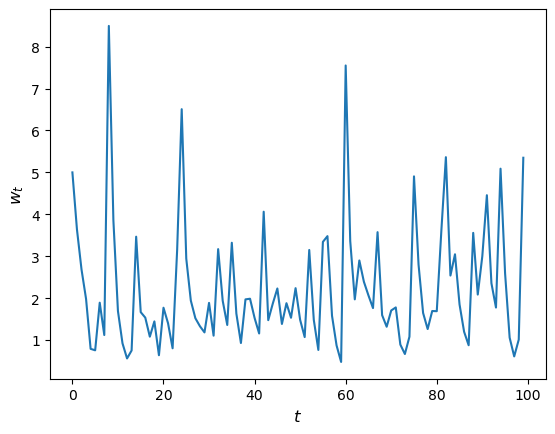

In [15]:
fig, ax = plt.subplots()

T = 100
w = np.empty(T)
w[0] = 5
for t in range(T-1):
    w[t+1] = update(w[t])

ax.plot(w)
ax.set_xlabel('$t$', fontsize=12)
ax.set_ylabel('$w_{t}$', fontsize=12)
plt.show()

حالا فرض کنیم که جمعیت زیادی از خانوارها داریم و می‌خواهیم بدانیم میانه ثروت چه خواهد بود.

حل این موضوع با مداد و کاغذ آسان نیست، بنابراین به جای آن از شبیه‌سازی استفاده خواهیم کرد:

1. تعداد زیادی از خانوارها را در طول زمان شبیه‌سازی می‌کنیم
2. میانه ثروت را محاسبه می‌کنیم

در اینجا کد است:

In [16]:
@jit
def compute_long_run_median(w0=1, T=1000, num_reps=50_000):
    obs = np.empty(num_reps)
    # For each household
    for i in range(num_reps):
        # Set the initial condition and run forward in time
        w = w0
        for t in range(T):
            w = update(w)
        # Record the final value
        obs[i] = w
    # Take the median of all final values
    return np.median(obs)

بیایید ببینیم چقدر سریع اجرا می‌شود:

In [17]:
with qe.Timer():
    # Warm up
    compute_long_run_median()

4.2362 seconds elapsed


In [18]:
with qe.Timer():
    # Second run
    compute_long_run_median()

3.5652 seconds elapsed


برای تسریع این، آن را از طریق چندنخی موازی‌سازی خواهیم کرد.

برای این کار، پرچم `parallel=True` را اضافه کرده و `range` را به `prange` تغییر می‌دهیم:

In [19]:
from numba import prange

@jit(parallel=True)
def compute_long_run_median_parallel(
        w0=1, T=1000, num_reps=50_000
    ):
    obs = np.empty(num_reps)
    for i in prange(num_reps):  # Parallelize over households
        w = w0
        for t in range(T):
            w = update(w)
        obs[i] = w
    return np.median(obs)

بیایید به زمان‌بندی نگاه کنیم:

In [20]:
with qe.Timer():
    # Warm up
    compute_long_run_median_parallel()

1.1227 seconds elapsed


In [21]:
with qe.Timer():
    # Second run
    compute_long_run_median_parallel()

0.7608 seconds elapsed


افزایش سرعت قابل توجه است.

توجه داشته باشید که موازی‌سازی را در سطح خانوارها انجام می‌دهیم نه در طول زمان -- به‌روزرسانی‌های یک خانوار منفرد در طول دوره‌های زمانی ذاتاً ترتیبی هستند.

برای موازی‌سازی مبتنی بر GPU، به {doc}`درس‌های ما درباره JAX <jax_intro>` مراجعه کنید.

## تمرین‌ها

```{exercise}
:label: speed_ex1

{ref}`قبلاً <pbe_ex5>` در نظر گرفتیم که چگونه $\pi$ را با Monte Carlo تقریب بزنیم.

از همان ایده اینجا استفاده کنید، اما کد را با استفاده از Numba کارآمد کنید.

سرعت را با و بدون Numba هنگامی که اندازه نمونه بزرگ است مقایسه کنید.
```

```{solution-start} speed_ex1
:class: dropdown
```

در اینجا یک راه‌حل است:

In [22]:
@jit
def calculate_pi(n=1_000_000):
    count = 0
    for i in range(n):
        u, v = np.random.uniform(0, 1), np.random.uniform(0, 1)
        d = np.sqrt((u - 0.5)**2 + (v - 0.5)**2)
        if d < 0.5:
            count += 1

    area_estimate = count / n
    return area_estimate * 4  # تقسیم بر radius**2

حالا بیایید ببینیم چقدر سریع اجرا می‌شود:

In [23]:
with qe.Timer():
    calculate_pi()

0.1155 seconds elapsed


In [24]:
with qe.Timer():
    calculate_pi()

0.0187 seconds elapsed


اگر کامپایل JIT را با حذف `@jit` خاموش کنیم، کد حدود 150 برابر بیشتر در دستگاه ما طول می‌کشد.

بنابراین با افزودن چهار کاراکتر، افزایش سرعت 2 مرتبه بزرگی به دست می‌آوریم.

```{solution-end}
```

```{exercise-start}
:label: speed_ex2
```

در سری سخنرانی [مقدمه‌ای بر اقتصاد کمی با Python](https://intro.quantecon.org/intro.html) می‌توانید همه چیز درباره زنجیره‌های مارکوف حالت محدود یاد بگیرید.

فعلاً، فقط روی شبیه‌سازی یک مثال بسیار ساده از چنین زنجیره‌ای تمرکز کنیم.

فرض کنید که نوسان بازده یک دارایی می‌تواند در یکی از دو رژیم باشد -- بالا یا پایین.

احتمالات انتقال در بین حالت‌ها به شرح زیر است

```{image} /_static/lecture_specific/sci_libs/nfs_ex1.png
:align: center
```

به عنوان مثال، فرض کنید طول دوره یک روز است و فرض کنید حالت فعلی بالا است.

از نمودار می‌بینیم که حالت فردا خواهد بود

* بالا با احتمال 0.8
* پایین با احتمال 0.2

وظیفه شما شبیه‌سازی یک دنباله از حالت‌های نوسان روزانه طبق این قانون است.

طول دنباله را `n = 1_000_000` تنظیم کنید و در حالت بالا شروع کنید.

یک نسخه Python خالص و یک نسخه Numba پیاده‌سازی کنید و سرعت‌ها را مقایسه کنید.

برای آزمایش کد خود، کسری از زمان که زنجیر در حالت پایین می‌گذراند را ارزیابی کنید.

اگر کد شما صحیح باشد، باید حدود 2/3 باشد.


```{hint}
:class: dropdown

* حالت پایین را به عنوان 0 و حالت بالا را به عنوان 1 نمایش دهید.
* اگر می‌خواهید اعداد صحیح را در یک آرایه NumPy ذخیره کنید و سپس کامپایل JIT اعمال کنید، از `x = np.empty(n, dtype=np.int64)` استفاده کنید.

```

```{exercise-end}
```

```{solution-start} speed_ex2
:class: dropdown
```

ما قرار می‌دهیم

- 0 نشان‌دهنده "پایین"
- 1 نشان‌دهنده "بالا"

In [25]:
p, q = 0.1, 0.2  # احتمال خروج از حالت پایین و بالا به ترتیب

در اینجا نسخه Python خالص تابع است

In [26]:
def compute_series(n):
    x = np.empty(n, dtype=np.int64)
    x[0] = 1  # در حالت 1 شروع کن
    U = np.random.uniform(0, 1, size=n)
    for t in range(1, n):
        current_x = x[t-1]
        if current_x == 0:
            x[t] = U[t] < p
        else:
            x[t] = U[t] > q
    return x

بیایید این کد را اجرا کنیم و بررسی کنیم که کسری از زمان صرف شده در حالت پایین حدود 0.666 است

In [27]:
n = 1_000_000
x = compute_series(n)
print(np.mean(x == 0))  # کسری از زمان که x در حالت 0 است

0.666822


این (تقریباً) خروجی صحیح است.

حالا بیایید زمان آن را بگیریم:

In [28]:
with qe.Timer():
    compute_series(n)

0.3338 seconds elapsed


بعد بیایید یک نسخه Numba پیاده‌سازی کنیم که آسان است

In [29]:
compute_series_numba = jit(compute_series)

بیایید بررسی کنیم که هنوز اعداد صحیح دریافت می‌کنیم

In [30]:
x = compute_series_numba(n)
print(np.mean(x == 0))

0.665951


بیایید زمان را ببینیم

In [31]:
with qe.Timer():
    compute_series_numba(n)

0.0109 seconds elapsed


این بهبود سرعت خوبی برای یک خط کد است!

```{solution-end}
```

```{exercise}
:label: numba_ex3

در {ref}`یک تمرین قبلی <speed_ex1>`، از Numba برای تسریع تلاشی برای محاسبه ثابت $\pi$ با Monte Carlo استفاده کردیم.

اکنون سعی کنید موازی‌سازی را اضافه کنید و ببینید آیا افزایش سرعت بیشتری به دست می‌آورید.

نباید انتظار افزایش بزرگی در اینجا داشته باشید زیرا، در حالی که وظایف مستقل زیادی وجود دارد (کشیدن نقطه و آزمایش اگر در دایره است)، هر کدام زمان اجرای کمی دارد.

به طور کلی، موازی‌سازی زمانی کمتر موثر است که وظایف فردی که باید موازی شوند نسبت به کل زمان اجرا بسیار کوچک باشند.

این به دلیل سربارهای مرتبط با توزیع همه این وظایف کوچک در چندین CPU است.

با این وجود، با سخت‌افزار مناسب، امکان به دست آوردن افزایش سرعت غیر بدیهی در این تمرین وجود دارد.

برای اندازه شبیه‌سازی Monte Carlo، از چیزی قابل توجه استفاده کنید، مانند `n = 100_000_000`.
```

```{solution-start} numba_ex3
:class: dropdown
```

در اینجا یک راه‌حل است:

In [32]:
@jit(parallel=True)
def calculate_pi(n=1_000_000):
    count = 0
    for i in prange(n):
        u, v = np.random.uniform(0, 1), np.random.uniform(0, 1)
        d = np.sqrt((u - 0.5)**2 + (v - 0.5)**2)
        if d < 0.5:
            count += 1

    area_estimate = count / n
    return area_estimate * 4  # تقسیم بر radius**2

حالا بیایید ببینیم چقدر سریع اجرا می‌شود:

In [33]:
with qe.Timer():
    calculate_pi()

0.3166 seconds elapsed


In [34]:
with qe.Timer():
    calculate_pi()

0.0036 seconds elapsed


با روشن و خاموش کردن موازی‌سازی (انتخاب `True` یا `False` در annotation `@jit`)، می‌توانیم افزایش سرعتی که چندنخی علاوه بر کامپایل JIT فراهم می‌کند را آزمایش کنیم.

در ایستگاه کاری ما، می‌بینیم که موازی‌سازی سرعت اجرا را با ضریب 2 یا 3 افزایش می‌دهد.

(اگر به صورت محلی اجرا می‌کنید، اعداد متفاوتی خواهید گرفت که عمدتاً به تعداد CPUها در دستگاه شما بستگی دارد.)

```{solution-end}
```


```{exercise}
:label: numba_ex4

در {doc}`درس ما درباره SciPy<scipy>`، قیمت‌گذاری یک اختیار خرید را در تنظیمی که قیمت سهام پایه یک توزیع ساده و شناخته شده داشت بحث کردیم.

در اینجا یک تنظیم واقعی‌تر را بحث می‌کنیم.

یادآوری می‌کنیم که قیمت اختیار از قانون زیر پیروی می‌کند

$$
P = \beta^n \mathbb E \max\{ S_n - K, 0 \}
$$

که در آن

1. $\beta$ یک فاکتور تنزیل است،
2. $n$ تاریخ انقضا است،
2. $K$ قیمت اعمال است و
3. $\{S_t\}$ قیمت دارایی پایه در هر زمان $t$ است.

فرض کنید که `n, β, K = 20, 0.99, 100`.

فرض کنید که قیمت سهام از قانون زیر پیروی می‌کند

$$
\ln \frac{S_{t+1}}{S_t} = \mu + \sigma_t \xi_{t+1}
$$

که در آن

$$
    \sigma_t = \exp(h_t),
    \quad
        h_{t+1} = \rho h_t + \nu \eta_{t+1}
$$

در اینجا $\{\xi_t\}$ و $\{\eta_t\}$ IID و نرمال استاندارد هستند.

(این یک مدل **نوسان تصادفی** است، که در آن نوسان $\sigma_t$ در طول زمان تغییر می‌کند.)

از مقادیر پیش‌فرض `μ, ρ, ν, S0, h0 = 0.0001, 0.1, 0.001, 10, 0` استفاده کنید.

(در اینجا `S0` همان $S_0$ و `h0` همان $h_0$ است.)

با تولید $M$ مسیر $s_0, \ldots, s_n$، تخمین Monte Carlo را محاسبه کنید

$$
    \hat P_M
    := \beta^n \mathbb E \max\{ S_n - K, 0 \}
    \approx
    \frac{1}{M} \sum_{m=1}^M \max \{S_n^m - K, 0 \}
$$


از قیمت، با اعمال Numba و موازی‌سازی.

```


```{solution-start} numba_ex4
:class: dropdown
```


با $s_t := \ln S_t$، پویایی قیمت به شکل زیر می‌شود

$$
s_{t+1} = s_t + \mu + \exp(h_t) \xi_{t+1}
$$

با استفاده از این واقعیت، راه‌حل را می‌توان به شرح زیر نوشت.

In [35]:
M = 10_000_000

n, β, K = 20, 0.99, 100
μ, ρ, ν, S0, h0 = 0.0001, 0.1, 0.001, 10, 0

@jit(parallel=True)
def compute_call_price_parallel(β=β,
                                μ=μ,
                                S0=S0,
                                h0=h0,
                                K=K,
                                n=n,
                                ρ=ρ,
                                ν=ν,
                                M=M):
    current_sum = 0.0
    # برای هر مسیر نمونه
    for m in prange(M):
        s = np.log(S0)
        h = h0
        # شبیه‌سازی رو به جلو در زمان
        for t in range(n):
            s = s + μ + np.exp(h) * np.random.randn()
            h = ρ * h + ν * np.random.randn()
        # و مقدار max{S_n - K, 0} را به current_sum اضافه کن
        current_sum += max(np.exp(s) - K, 0)

    return β**n * current_sum / M

سعی کنید بین `parallel=True` و `parallel=False` جابجا شوید و زمان اجرا را یادداشت کنید.

اگر روی دستگاهی با CPUهای زیاد هستید، تفاوت باید قابل توجه باشد.

```{solution-end}
```